<a href="https://colab.research.google.com/github/varaiitj2527/PRMLProject/blob/main/Model/Artificial_Neural_Network_Models/ANN_(With_resnet)_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!git clone https://github.com/varaiitj2527/PRMLProject.git
%cd PRMLProject

Cloning into 'PRMLProject'...
remote: Enumerating objects: 118, done.
remote: Counting objects: 100% (100/100), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 118 (delta 32), reused 21 (delta 2), pack-reused 18 (from 2)
Receiving objects: 100% (118/118), 206.29 MiB | 16.05 MiB/s, done.
Resolving deltas: 100% (32/32), done.
Updating files: 100% (40/40), done.
Filtering content: 100% (14/14), 1.29 GiB | 42.73 MiB/s, done.
Encountered 2 file(s) that should have been pointers, but weren't:
	PreProcessedData/quicknet_test.pkl
	PreProcessedData/quicknet_train.pkl
/content/PRMLProject


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold
from tqdm import tqdm
import pickle

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten,LeakyReLU, BatchNormalization, Activation
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [4]:
def unpickle(file):   # Function for unpickling the file
    with open(file, 'rb') as f:
        return pickle.load(f)

In [5]:
X_train_mlp_resnet=np.array(unpickle("PreProcessedData/Resnet_train.pkl"))
print(X_train_mlp_resnet.shape)
y_train_main=unpickle("PreProcessedData/Labels_train.pkl")
print(y_train_main.shape)
X_test_mlp_resnet=np.array(unpickle("PreProcessedData/Resnet_test.pkl"))
#print(X_test_mlp_resnet.shape)
y_test_main=unpickle("PreProcessedData/Labels_test.pkl")

(50000, 2048)
(50000,)


In [6]:
X_train, X_val, y_train, y_val = train_test_split(X_train_mlp_resnet, y_train_main, test_size=0.2, random_state=42)

In [7]:
print(X_train.shape)
print(X_val.shape)

(40000, 2048)
(10000, 2048)


# Trial 1 (Overfitting and signs of confusion)

In [8]:
model = Sequential([  # SIGNS OF OVERFITTING
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 558,730 (2.13 MB)

 Trainable params: 558,730 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=128,
    verbose=2
)

Epoch 1/40
313/313 - 5s - 16ms/step - accuracy: 0.8342 - loss: 0.4789 - val_accuracy: 0.8702 - val_loss: 0.3687
Epoch 2/40
313/313 - 1s - 3ms/step - accuracy: 0.8781 - loss: 0.3473 - val_accuracy: 0.8701 - val_loss: 0.3707
Epoch 3/40
313/313 - 1s - 3ms/step - accuracy: 0.8856 - loss: 0.3198 - val_accuracy: 0.8807 - val_loss: 0.3411
Epoch 4/40
313/313 - 1s - 4ms/step - accuracy: 0.8942 - loss: 0.2970 - val_accuracy: 0.8914 - val_loss: 0.3165
Epoch 5/40
313/313 - 1s - 3ms/step - accuracy: 0.9001 - loss: 0.2796 - val_accuracy: 0.8772 - val_loss: 0.3537
Epoch 6/40
313/313 - 1s - 3ms/step - accuracy: 0.9075 - loss: 0.2599 - val_accuracy: 0.8912 - val_loss: 0.3213
Epoch 7/40
313/313 - 1s - 4ms/step - accuracy: 0.9130 - loss: 0.2435 - val_accuracy: 0.8924 - val_loss: 0.3222
Epoch 8/40
313/313 - 1s - 4ms/step - accuracy: 0.9220 - loss: 0.2202 - val_accuracy: 0.8888 - val_loss: 0.3173
Epoch 9/40
313/313 - 2s - 7ms/step - accuracy: 0.9252 - loss: 0.2064 - val_accuracy: 0.8906 - val_loss: 0.3291


In [12]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print("Validation Accuracy: ",val_acc)
print("Validation loss: ",val_loss)

Validation Accuracy:  0.8863999843597412
Validation loss:  0.7186501026153564


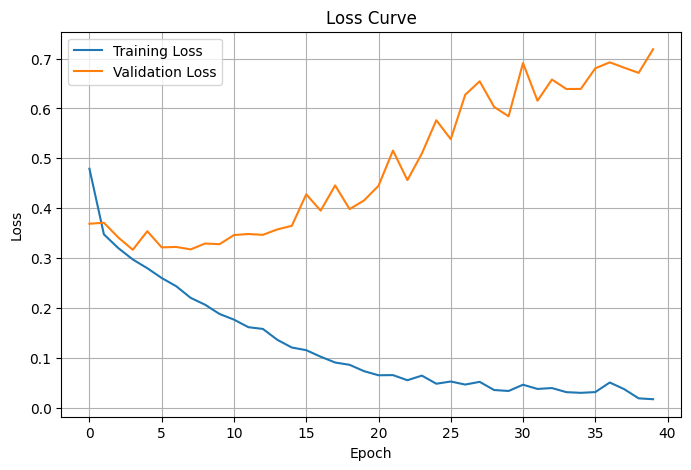

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

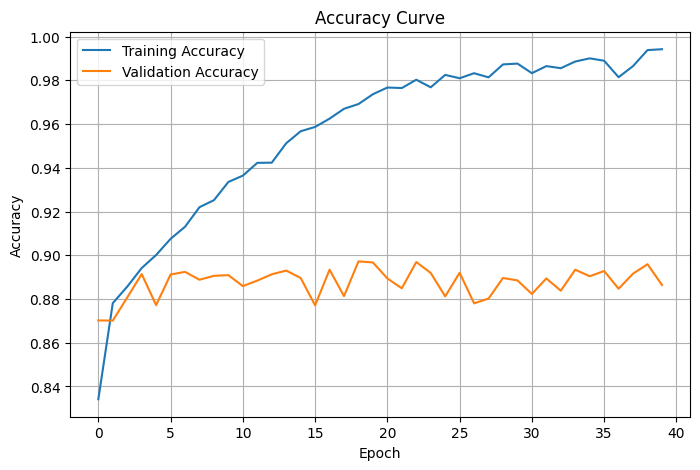

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Trial 2  (Overfitting and signs of confusion)

In [15]:
model = Sequential([   # OVERFITTING TOO MUCH
    Dense(256,input_shape=(X_train.shape[1],)),
    LeakyReLU(alpha=0.01),
    Dense(128),
    LeakyReLU(alpha=0.01),
    Dense(10, activation='softmax')
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


In [16]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [17]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 558,730 (2.13 MB)

 Trainable params: 558,730 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    verbose=2
)

Epoch 1/50
313/313 - 5s - 16ms/step - accuracy: 0.8314 - loss: 0.4827 - val_accuracy: 0.8465 - val_loss: 0.4378
Epoch 2/50
313/313 - 1s - 3ms/step - accuracy: 0.8748 - loss: 0.3599 - val_accuracy: 0.8613 - val_loss: 0.4093
Epoch 3/50
313/313 - 1s - 3ms/step - accuracy: 0.8864 - loss: 0.3262 - val_accuracy: 0.8820 - val_loss: 0.3440
Epoch 4/50
313/313 - 1s - 4ms/step - accuracy: 0.8944 - loss: 0.3008 - val_accuracy: 0.8752 - val_loss: 0.3593
Epoch 5/50
313/313 - 1s - 3ms/step - accuracy: 0.9027 - loss: 0.2738 - val_accuracy: 0.8894 - val_loss: 0.3203
Epoch 6/50
313/313 - 1s - 3ms/step - accuracy: 0.9071 - loss: 0.2595 - val_accuracy: 0.8956 - val_loss: 0.3107
Epoch 7/50
313/313 - 1s - 3ms/step - accuracy: 0.9174 - loss: 0.2329 - val_accuracy: 0.8797 - val_loss: 0.3585
Epoch 8/50
313/313 - 1s - 4ms/step - accuracy: 0.9229 - loss: 0.2156 - val_accuracy: 0.8906 - val_loss: 0.3254
Epoch 9/50
313/313 - 1s - 3ms/step - accuracy: 0.9255 - loss: 0.2054 - val_accuracy: 0.8904 - val_loss: 0.3424


In [19]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print("Validation Accuracy: ",val_acc)
print("Validation loss: ",val_loss)

Validation Accuracy:  0.8877000212669373
Validation loss:  0.8185694217681885


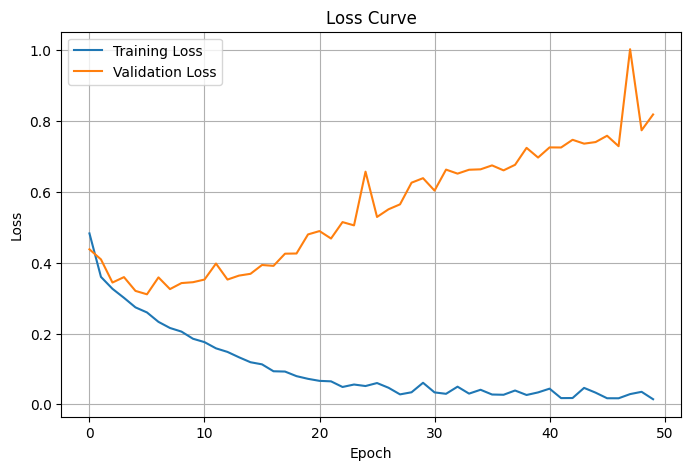

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

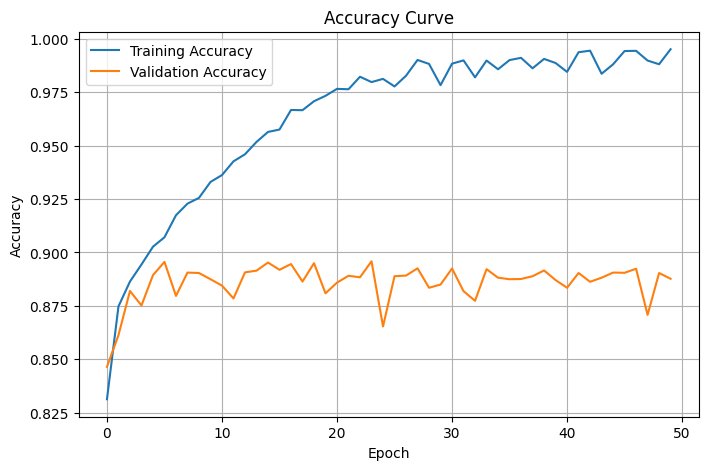

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Trial 3 (Overfitting and signs of confusion)

In [22]:
model = Sequential([
    Dense(128,input_shape=(X_train.shape[1],)),
    Dense(64,activation='relu'),
    Dense(10, activation='softmax')
])


In [23]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [24]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 271,178 (1.03 MB)

 Trainable params: 271,178 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=64,
    verbose=2
)

Epoch 1/50
625/625 - 5s - 8ms/step - accuracy: 0.8301 - loss: 0.4928 - val_accuracy: 0.8736 - val_loss: 0.3620
Epoch 2/50
625/625 - 3s - 5ms/step - accuracy: 0.8727 - loss: 0.3670 - val_accuracy: 0.8718 - val_loss: 0.3680
Epoch 3/50
625/625 - 2s - 4ms/step - accuracy: 0.8825 - loss: 0.3350 - val_accuracy: 0.8692 - val_loss: 0.3862
Epoch 4/50
625/625 - 2s - 3ms/step - accuracy: 0.8894 - loss: 0.3149 - val_accuracy: 0.8855 - val_loss: 0.3385
Epoch 5/50
625/625 - 3s - 4ms/step - accuracy: 0.8922 - loss: 0.3020 - val_accuracy: 0.8806 - val_loss: 0.3454
Epoch 6/50
625/625 - 2s - 3ms/step - accuracy: 0.8982 - loss: 0.2881 - val_accuracy: 0.8843 - val_loss: 0.3407
Epoch 7/50
625/625 - 2s - 3ms/step - accuracy: 0.9031 - loss: 0.2752 - val_accuracy: 0.8801 - val_loss: 0.3537
Epoch 8/50
625/625 - 3s - 4ms/step - accuracy: 0.9050 - loss: 0.2653 - val_accuracy: 0.8860 - val_loss: 0.3386
Epoch 9/50
625/625 - 4s - 7ms/step - accuracy: 0.9103 - loss: 0.2503 - val_accuracy: 0.8748 - val_loss: 0.3728
E

In [26]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print("Validation Accuracy: ",val_acc)
print("Validation loss: ",val_loss)

Validation Accuracy:  0.8791000247001648
Validation loss:  0.6947582364082336


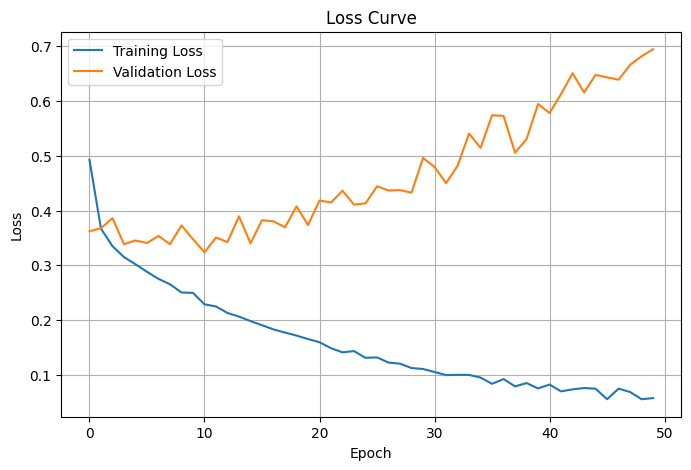

In [27]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

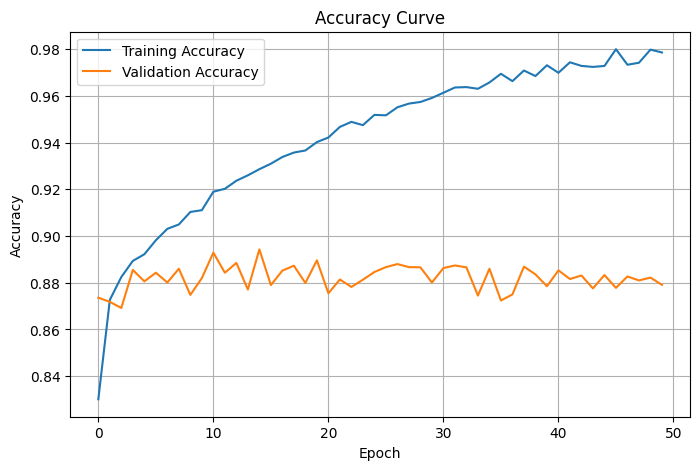

In [28]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Trial 4  (Overfitting and confused)

In [29]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(10, activation='softmax')
])


In [30]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [31]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                      │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 263,562 (1.01 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 0 (0.00 B)

In [32]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=128,
    verbose=2
)

Epoch 1/40
313/313 - 3s - 10ms/step - accuracy: 0.8314 - loss: 0.4893 - val_accuracy: 0.8678 - val_loss: 0.3775
Epoch 2/40
313/313 - 1s - 3ms/step - accuracy: 0.8778 - loss: 0.3491 - val_accuracy: 0.8770 - val_loss: 0.3504
Epoch 3/40
313/313 - 1s - 4ms/step - accuracy: 0.8858 - loss: 0.3247 - val_accuracy: 0.8857 - val_loss: 0.3304
Epoch 4/40
313/313 - 1s - 3ms/step - accuracy: 0.8929 - loss: 0.3018 - val_accuracy: 0.8854 - val_loss: 0.3288
Epoch 5/40
313/313 - 1s - 4ms/step - accuracy: 0.8970 - loss: 0.2884 - val_accuracy: 0.8737 - val_loss: 0.3523
Epoch 6/40
313/313 - 1s - 4ms/step - accuracy: 0.9046 - loss: 0.2691 - val_accuracy: 0.8938 - val_loss: 0.3068
Epoch 7/40
313/313 - 1s - 5ms/step - accuracy: 0.9082 - loss: 0.2584 - val_accuracy: 0.8758 - val_loss: 0.3413
Epoch 8/40
313/313 - 2s - 7ms/step - accuracy: 0.9142 - loss: 0.2437 - val_accuracy: 0.8926 - val_loss: 0.3080
Epoch 9/40
313/313 - 1s - 3ms/step - accuracy: 0.9160 - loss: 0.2369 - val_accuracy: 0.8821 - val_loss: 0.3474


In [33]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print("Validation Accuracy: ",val_acc)
print("Validation loss: ",val_loss)

Validation Accuracy:  0.8942000269889832
Validation loss:  0.51066654920578


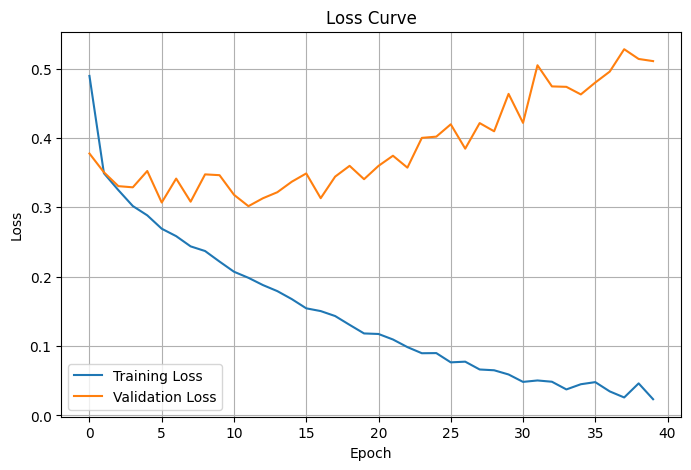

In [34]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

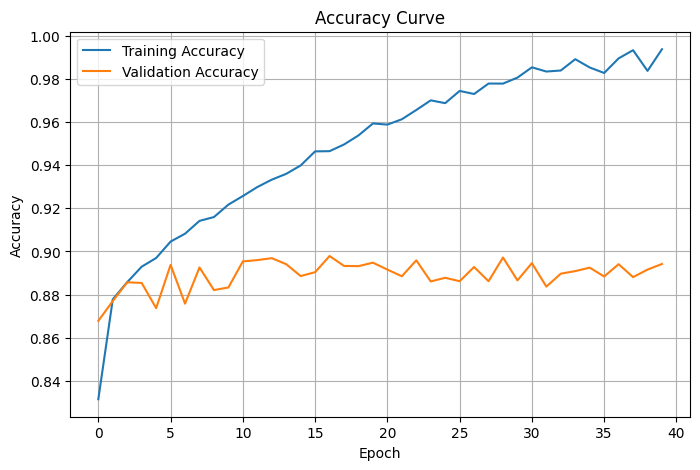

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Trial 5 (Getting better)

In [36]:
model = Sequential([ # Getting better
    Dense(512, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])


In [37]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [38]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                     │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 10)                  │           2,570 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,182,986 (4.51 MB)

 Trainable params: 1,182,986 (4.51 MB)

 Non-trainable params: 0 (0.00 B)

In [39]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=40,
    batch_size=128,
    verbose=2
)

Epoch 1/40
313/313 - 8s - 24ms/step - accuracy: 0.7503 - loss: 0.7402 - val_accuracy: 0.8513 - val_loss: 0.4367
Epoch 2/40
313/313 - 5s - 16ms/step - accuracy: 0.8290 - loss: 0.5227 - val_accuracy: 0.8739 - val_loss: 0.3827
Epoch 3/40
313/313 - 1s - 3ms/step - accuracy: 0.8399 - loss: 0.4838 - val_accuracy: 0.8759 - val_loss: 0.3688
Epoch 4/40
313/313 - 1s - 4ms/step - accuracy: 0.8494 - loss: 0.4592 - val_accuracy: 0.8787 - val_loss: 0.3653
Epoch 5/40
313/313 - 2s - 5ms/step - accuracy: 0.8561 - loss: 0.4342 - val_accuracy: 0.8852 - val_loss: 0.3467
Epoch 6/40
313/313 - 1s - 3ms/step - accuracy: 0.8617 - loss: 0.4226 - val_accuracy: 0.8845 - val_loss: 0.3539
Epoch 7/40
313/313 - 1s - 4ms/step - accuracy: 0.8625 - loss: 0.4110 - val_accuracy: 0.8805 - val_loss: 0.3505
Epoch 8/40
313/313 - 1s - 4ms/step - accuracy: 0.8676 - loss: 0.3951 - val_accuracy: 0.8886 - val_loss: 0.3379
Epoch 9/40
313/313 - 1s - 3ms/step - accuracy: 0.8704 - loss: 0.3852 - val_accuracy: 0.8829 - val_loss: 0.3370

In [40]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print("Validation Accuracy: ",val_acc)
print("Validation loss: ",val_loss)

Validation Accuracy:  0.8930000066757202
Validation loss:  0.3104340732097626


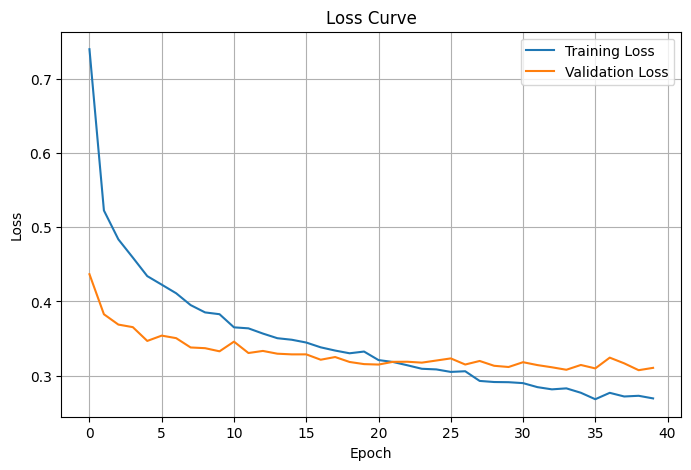

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

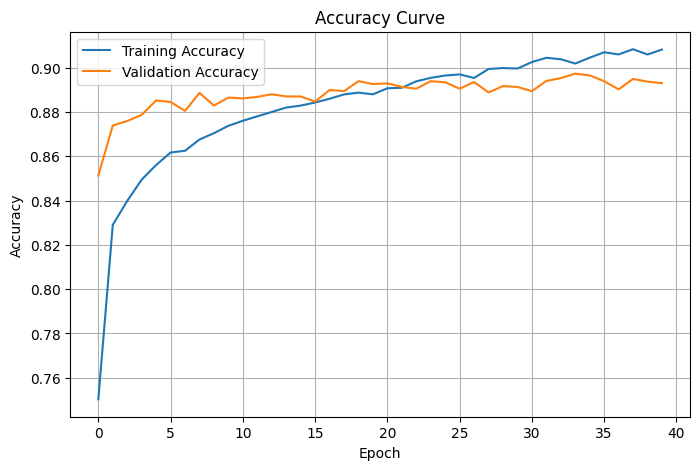

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Trial 6 (Getting better)

In [43]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])


In [44]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [45]:
model.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_14 (Dense)                     │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_15 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 558,730 (2.13 MB)

 Trainable params: 558,730 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [46]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    verbose=2
)

Epoch 1/50
313/313 - 6s - 18ms/step - accuracy: 0.7088 - loss: 0.8561 - val_accuracy: 0.8534 - val_loss: 0.4343
Epoch 2/50
313/313 - 1s - 3ms/step - accuracy: 0.8181 - loss: 0.5635 - val_accuracy: 0.8655 - val_loss: 0.3955
Epoch 3/50
313/313 - 1s - 4ms/step - accuracy: 0.8323 - loss: 0.5163 - val_accuracy: 0.8760 - val_loss: 0.3738
Epoch 4/50
313/313 - 1s - 3ms/step - accuracy: 0.8429 - loss: 0.4917 - val_accuracy: 0.8756 - val_loss: 0.3725
Epoch 5/50
313/313 - 1s - 4ms/step - accuracy: 0.8500 - loss: 0.4609 - val_accuracy: 0.8776 - val_loss: 0.3600
Epoch 6/50
313/313 - 1s - 4ms/step - accuracy: 0.8551 - loss: 0.4434 - val_accuracy: 0.8816 - val_loss: 0.3543
Epoch 7/50
313/313 - 2s - 5ms/step - accuracy: 0.8591 - loss: 0.4314 - val_accuracy: 0.8790 - val_loss: 0.3584
Epoch 8/50
313/313 - 1s - 3ms/step - accuracy: 0.8614 - loss: 0.4233 - val_accuracy: 0.8770 - val_loss: 0.3616
Epoch 9/50
313/313 - 1s - 4ms/step - accuracy: 0.8634 - loss: 0.4186 - val_accuracy: 0.8842 - val_loss: 0.3393


In [47]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print("Validation Accuracy: ",val_acc)
print("Validation loss: ",val_loss)

Validation Accuracy:  0.8964999914169312
Validation loss:  0.3207687437534332


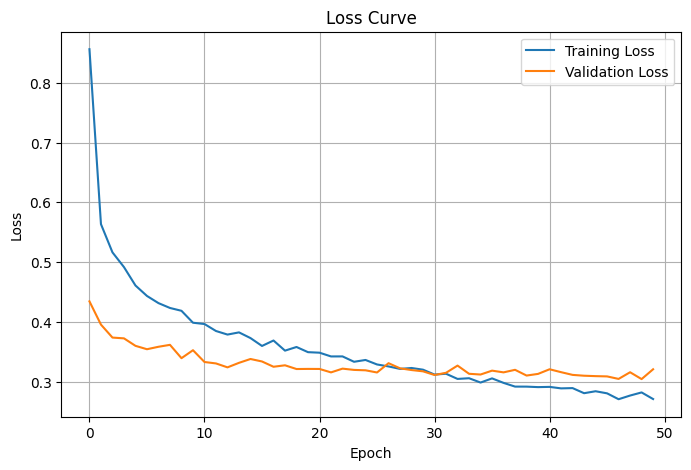

In [48]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

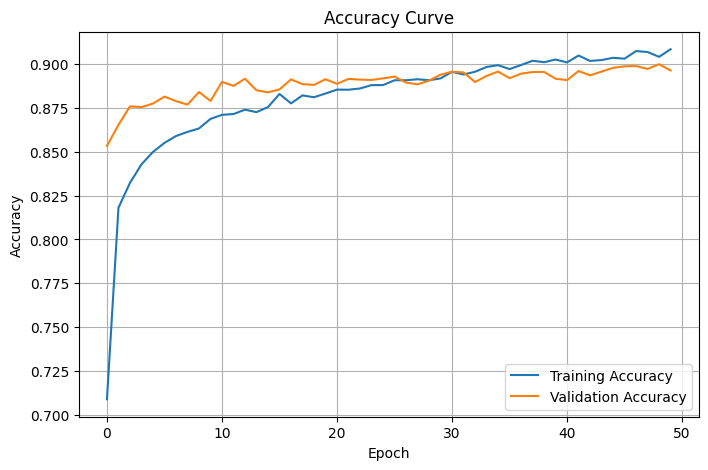

In [49]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Trial 7 (Underfitting)

In [50]:
model = Sequential([  # Underfitting, so 256, 128 is better
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])


In [51]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [52]:
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_17 (Dense)                     │ (None, 128)                 │         262,272 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 271,178 (1.03 MB)

 Trainable params: 271,178 (1.03 MB)

 Non-trainable params: 0 (0.00 B)

In [53]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    verbose=2
)

Epoch 1/50
313/313 - 7s - 23ms/step - accuracy: 0.5641 - loss: 1.2511 - val_accuracy: 0.8467 - val_loss: 0.5010
Epoch 2/50
313/313 - 1s - 3ms/step - accuracy: 0.7139 - loss: 0.8452 - val_accuracy: 0.8583 - val_loss: 0.4415
Epoch 3/50
313/313 - 1s - 4ms/step - accuracy: 0.7406 - loss: 0.7675 - val_accuracy: 0.8657 - val_loss: 0.4197
Epoch 4/50
313/313 - 1s - 4ms/step - accuracy: 0.7564 - loss: 0.7276 - val_accuracy: 0.8695 - val_loss: 0.4118
Epoch 5/50
313/313 - 1s - 3ms/step - accuracy: 0.7649 - loss: 0.7051 - val_accuracy: 0.8638 - val_loss: 0.4237
Epoch 6/50
313/313 - 1s - 3ms/step - accuracy: 0.7736 - loss: 0.6787 - val_accuracy: 0.8700 - val_loss: 0.4185
Epoch 7/50
313/313 - 1s - 4ms/step - accuracy: 0.7752 - loss: 0.6724 - val_accuracy: 0.8682 - val_loss: 0.4057
Epoch 8/50
313/313 - 1s - 5ms/step - accuracy: 0.7797 - loss: 0.6569 - val_accuracy: 0.8784 - val_loss: 0.3908
Epoch 9/50
313/313 - 2s - 7ms/step - accuracy: 0.7820 - loss: 0.6474 - val_accuracy: 0.8708 - val_loss: 0.4058


In [54]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print("Validation Accuracy: ",val_acc)
print("Validation loss: ",val_loss)

Validation Accuracy:  0.8925999999046326
Validation loss:  0.3371235728263855


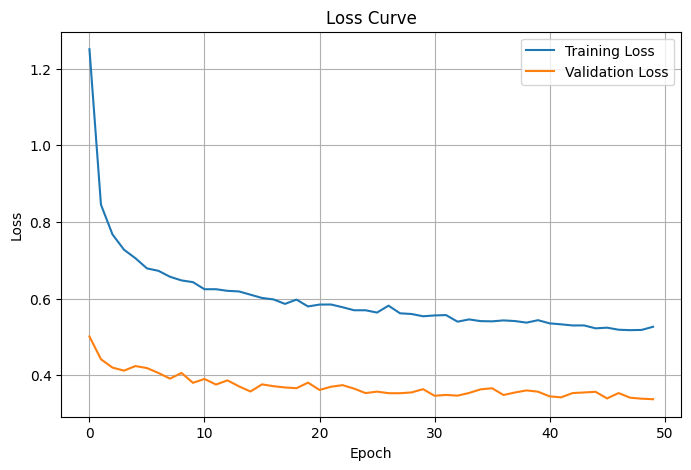

In [55]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

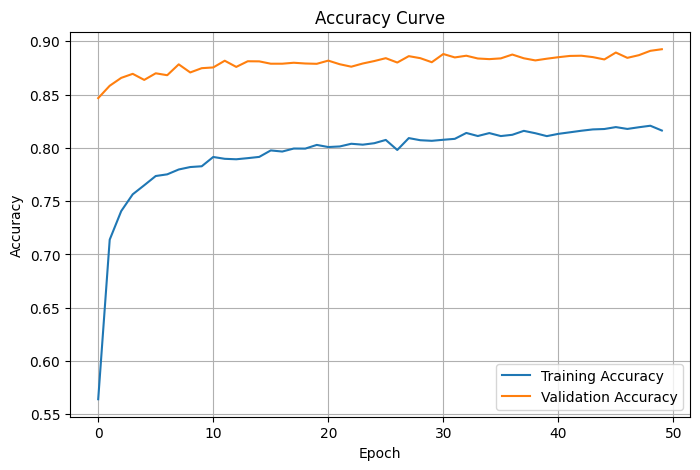

In [56]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Trial 8  (Model overfitting and also getting confused after 15th epoch)

In [57]:
model = Sequential([     # Model overfitting and also getting confused afte 15th epoch
    Dense(256, input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(128),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.5),

    Dense(10, activation='softmax')
])

In [58]:
model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [59]:
model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_20 (Dense)                     │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 560,266 (2.14 MB)

 Trainable params: 559,498 (2.13 MB)

 Non-trainable params: 768 (3.00 KB)

In [60]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    verbose=2
)

Epoch 1/50
313/313 - 8s - 26ms/step - accuracy: 0.7870 - loss: 0.6529 - val_accuracy: 0.8670 - val_loss: 0.3845
Epoch 2/50
313/313 - 1s - 3ms/step - accuracy: 0.8532 - loss: 0.4446 - val_accuracy: 0.8857 - val_loss: 0.3365
Epoch 3/50
313/313 - 1s - 4ms/step - accuracy: 0.8663 - loss: 0.4034 - val_accuracy: 0.8879 - val_loss: 0.3277
Epoch 4/50
313/313 - 1s - 4ms/step - accuracy: 0.8739 - loss: 0.3832 - val_accuracy: 0.8903 - val_loss: 0.3278
Epoch 5/50
313/313 - 1s - 4ms/step - accuracy: 0.8813 - loss: 0.3557 - val_accuracy: 0.8940 - val_loss: 0.3118
Epoch 6/50
313/313 - 1s - 4ms/step - accuracy: 0.8850 - loss: 0.3377 - val_accuracy: 0.8948 - val_loss: 0.3079
Epoch 7/50
313/313 - 1s - 5ms/step - accuracy: 0.8904 - loss: 0.3222 - val_accuracy: 0.8921 - val_loss: 0.3088
Epoch 8/50
313/313 - 1s - 3ms/step - accuracy: 0.8948 - loss: 0.3123 - val_accuracy: 0.8977 - val_loss: 0.2955
Epoch 9/50
313/313 - 1s - 4ms/step - accuracy: 0.8980 - loss: 0.3005 - val_accuracy: 0.8952 - val_loss: 0.3037


In [61]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print("Validation Accuracy: ",val_acc)
print("Validation loss: ",val_loss)

Validation Accuracy:  0.9025999903678894
Validation loss:  0.36187323927879333


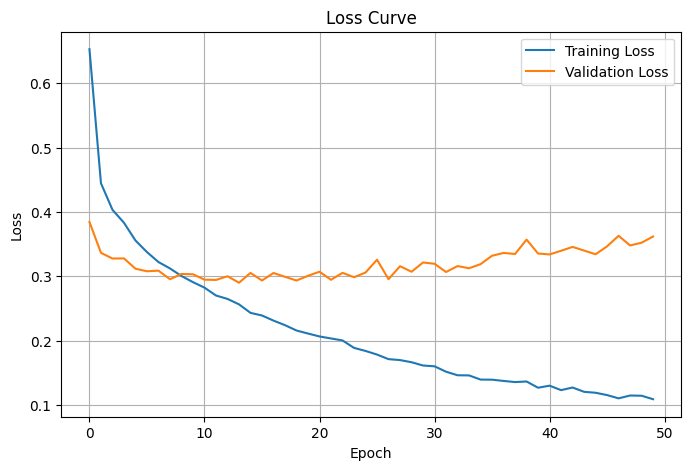

In [62]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

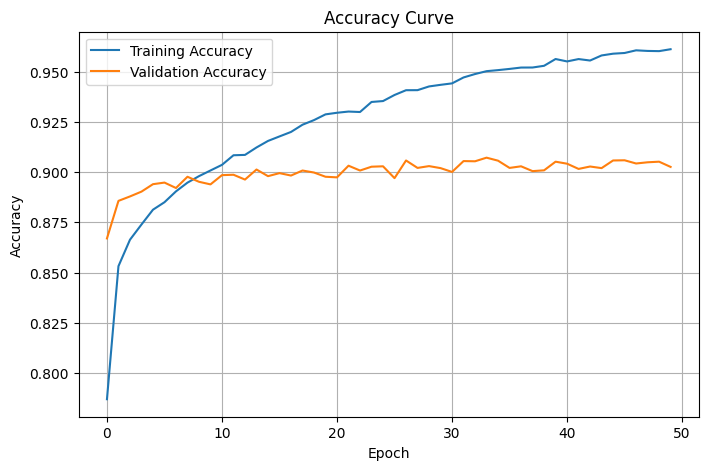

In [63]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Trial 9 (Getting better)

In [64]:
model = Sequential([  # Getting better
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])


In [65]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [66]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                     │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_9 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 558,730 (2.13 MB)

 Trainable params: 558,730 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    verbose=2
)

Epoch 1/50
313/313 - 6s - 18ms/step - accuracy: 0.5115 - loss: 1.4214 - val_accuracy: 0.8188 - val_loss: 0.6045
Epoch 2/50
313/313 - 2s - 6ms/step - accuracy: 0.7428 - loss: 0.7767 - val_accuracy: 0.8489 - val_loss: 0.4657
Epoch 3/50
313/313 - 1s - 3ms/step - accuracy: 0.7945 - loss: 0.6344 - val_accuracy: 0.8600 - val_loss: 0.4227
Epoch 4/50
313/313 - 1s - 4ms/step - accuracy: 0.8172 - loss: 0.5686 - val_accuracy: 0.8699 - val_loss: 0.3974
Epoch 5/50
313/313 - 1s - 3ms/step - accuracy: 0.8293 - loss: 0.5266 - val_accuracy: 0.8756 - val_loss: 0.3800
Epoch 6/50
313/313 - 1s - 3ms/step - accuracy: 0.8395 - loss: 0.4963 - val_accuracy: 0.8774 - val_loss: 0.3716
Epoch 7/50
313/313 - 1s - 4ms/step - accuracy: 0.8465 - loss: 0.4739 - val_accuracy: 0.8755 - val_loss: 0.3689
Epoch 8/50
313/313 - 1s - 4ms/step - accuracy: 0.8519 - loss: 0.4581 - val_accuracy: 0.8817 - val_loss: 0.3569
Epoch 9/50
313/313 - 2s - 7ms/step - accuracy: 0.8582 - loss: 0.4391 - val_accuracy: 0.8821 - val_loss: 0.3521


In [68]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print("Validation Accuracy: ",val_acc)
print("Validation loss: ",val_loss)

Validation Accuracy:  0.900600016117096
Validation loss:  0.3138408362865448


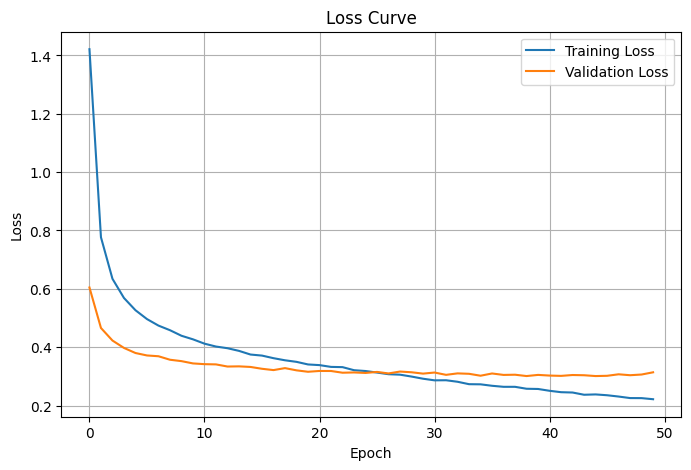

In [69]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

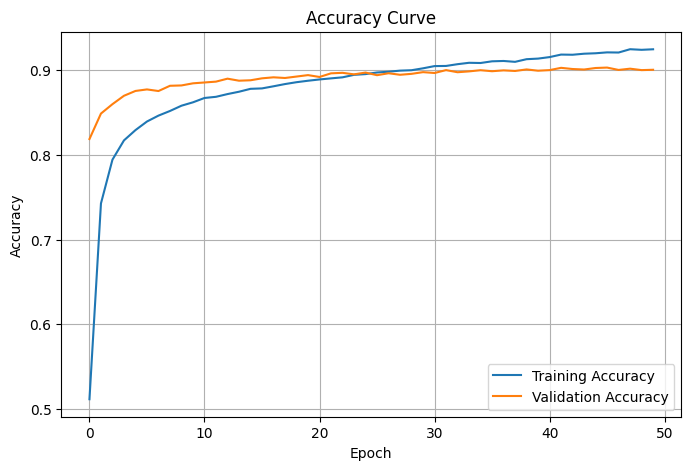

In [70]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Trial 10 (Getting better)

In [71]:
model = Sequential([  # Getting better
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])


In [72]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [73]:
model.summary()

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_26 (Dense)                     │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_10 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_11 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 558,730 (2.13 MB)

 Trainable params: 558,730 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [74]:
early_stopper = EarlyStopping(monitor='val_loss', patience=12, verbose=1, restore_best_weights=True)

In [75]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[early_stopper],
    verbose=2
)

Epoch 1/50
313/313 - 6s - 18ms/step - accuracy: 0.5158 - loss: 1.3897 - val_accuracy: 0.8163 - val_loss: 0.5993
Epoch 2/50
313/313 - 1s - 3ms/step - accuracy: 0.7458 - loss: 0.7675 - val_accuracy: 0.8457 - val_loss: 0.4650
Epoch 3/50
313/313 - 1s - 4ms/step - accuracy: 0.7902 - loss: 0.6345 - val_accuracy: 0.8621 - val_loss: 0.4177
Epoch 4/50
313/313 - 1s - 3ms/step - accuracy: 0.8190 - loss: 0.5603 - val_accuracy: 0.8682 - val_loss: 0.3975
Epoch 5/50
313/313 - 1s - 3ms/step - accuracy: 0.8334 - loss: 0.5156 - val_accuracy: 0.8730 - val_loss: 0.3792
Epoch 6/50
313/313 - 1s - 4ms/step - accuracy: 0.8407 - loss: 0.4895 - val_accuracy: 0.8733 - val_loss: 0.3771
Epoch 7/50
313/313 - 1s - 3ms/step - accuracy: 0.8460 - loss: 0.4704 - val_accuracy: 0.8774 - val_loss: 0.3588
Epoch 8/50
313/313 - 2s - 5ms/step - accuracy: 0.8529 - loss: 0.4513 - val_accuracy: 0.8789 - val_loss: 0.3564
Epoch 9/50
313/313 - 1s - 4ms/step - accuracy: 0.8589 - loss: 0.4377 - val_accuracy: 0.8812 - val_loss: 0.3511


In [76]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print("Validation Accuracy: ",val_acc)
print("Validation loss: ",val_loss)

Validation Accuracy:  0.902999997138977
Validation loss:  0.2960064113140106


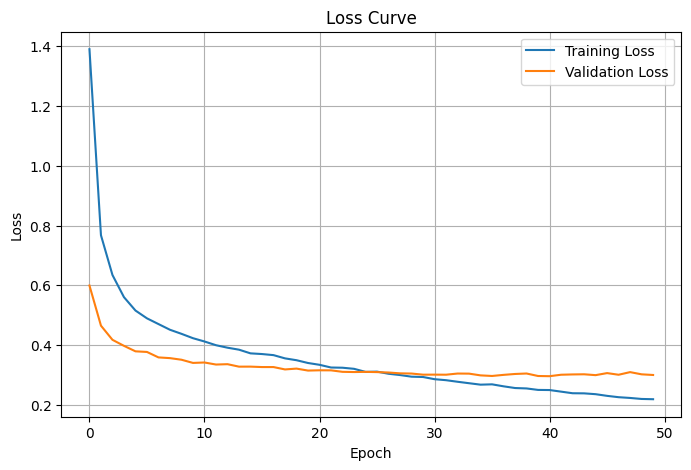

In [77]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

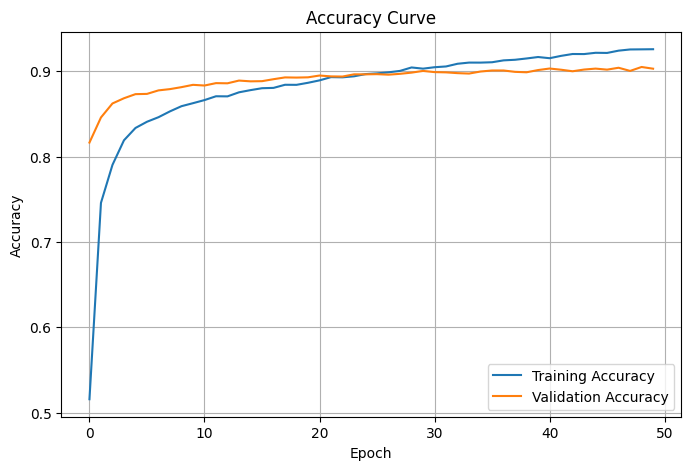

In [78]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Trial 11 (This one used finally)

In [79]:
model = Sequential([  # Getting better
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])


In [80]:
optimizer = Adam(learning_rate=0.0001)
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [81]:
model.summary()

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                     │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_12 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_13 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 558,730 (2.13 MB)

 Trainable params: 558,730 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [82]:
early_stopper = EarlyStopping(monitor='val_loss', patience=12, verbose=1, restore_best_weights=True)
r_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

In [83]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=128,
    callbacks=[early_stopper,r_reducer],
    verbose=2
)

Epoch 1/50
313/313 - 6s - 18ms/step - accuracy: 0.5177 - loss: 1.3911 - val_accuracy: 0.8233 - val_loss: 0.5880 - learning_rate: 1.0000e-04
Epoch 2/50
313/313 - 2s - 5ms/step - accuracy: 0.7467 - loss: 0.7615 - val_accuracy: 0.8488 - val_loss: 0.4598 - learning_rate: 1.0000e-04
Epoch 3/50
313/313 - 1s - 4ms/step - accuracy: 0.7926 - loss: 0.6297 - val_accuracy: 0.8623 - val_loss: 0.4123 - learning_rate: 1.0000e-04
Epoch 4/50
313/313 - 1s - 4ms/step - accuracy: 0.8180 - loss: 0.5566 - val_accuracy: 0.8671 - val_loss: 0.3950 - learning_rate: 1.0000e-04
Epoch 5/50
313/313 - 1s - 4ms/step - accuracy: 0.8299 - loss: 0.5239 - val_accuracy: 0.8726 - val_loss: 0.3793 - learning_rate: 1.0000e-04
Epoch 6/50
313/313 - 1s - 4ms/step - accuracy: 0.8393 - loss: 0.4880 - val_accuracy: 0.8748 - val_loss: 0.3660 - learning_rate: 1.0000e-04
Epoch 7/50
313/313 - 1s - 4ms/step - accuracy: 0.8456 - loss: 0.4711 - val_accuracy: 0.8776 - val_loss: 0.3601 - learning_rate: 1.0000e-04
Epoch 8/50
313/313 - 2s - 

In [84]:
val_loss, val_acc = model.evaluate(X_val, y_val, verbose=0)
print("Validation Accuracy: ",val_acc)
print("Validation loss: ",val_loss)

Validation Accuracy:  0.9027000069618225
Validation loss:  0.2944999039173126


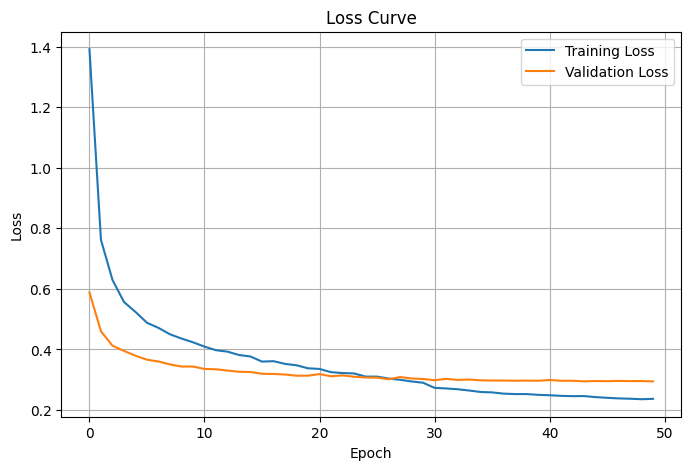

In [85]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

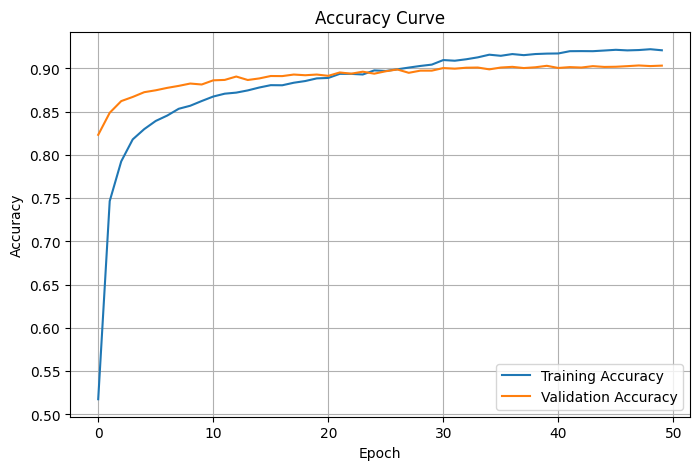

In [86]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Training on whole train set using trial 11 model

In [87]:
model = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),  # ReLU actvation
    Dropout(0.5), # Use dropout of 0.5 to randomly off 0.5 fraction of the neurons
    Dense(128, activation='relu'), # ReLU actvation
    Dropout(0.5),  # Use dropout of 0.5 to randomly off 0.5 fraction of the neurons
    Dense(10, activation='softmax')  # softmax actvation
])


In [88]:
optimizer = Adam(learning_rate=0.0001)  # Set learning rate to 0.0001 and optimizer used in Adam
model.compile(
    optimizer=optimizer,
    loss='sparse_categorical_crossentropy',  # loss fubction is sparse_categorical_crossentropy
    metrics=['accuracy']
)

In [89]:
model.summary()

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_32 (Dense)                     │ (None, 256)                 │         524,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_33 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_34 (Dense)                     │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 558,730 (2.13 MB)

 Trainable params: 558,730 (2.13 MB)

 Non-trainable params: 0 (0.00 B)

In [90]:
early_stopper = EarlyStopping(monitor='val_loss', patience=12, verbose=1, restore_best_weights=True) # Stop when no improvements seen after 12 epochs
r_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1) # Change lr when plot getting plateaued

In [91]:
history = model.fit(  # Fit training set
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50, # 50 epochs
    batch_size=128,
    callbacks=[early_stopper,r_reducer], # Put callbacks for early stopper and lr reducer
    verbose=2
)

Epoch 1/50
313/313 - 6s - 19ms/step - accuracy: 0.5331 - loss: 1.3560 - val_accuracy: 0.8221 - val_loss: 0.5745 - learning_rate: 1.0000e-04
Epoch 2/50
313/313 - 2s - 5ms/step - accuracy: 0.7455 - loss: 0.7585 - val_accuracy: 0.8455 - val_loss: 0.4633 - learning_rate: 1.0000e-04
Epoch 3/50
313/313 - 1s - 4ms/step - accuracy: 0.7918 - loss: 0.6306 - val_accuracy: 0.8590 - val_loss: 0.4163 - learning_rate: 1.0000e-04
Epoch 4/50
313/313 - 1s - 3ms/step - accuracy: 0.8156 - loss: 0.5626 - val_accuracy: 0.8647 - val_loss: 0.3993 - learning_rate: 1.0000e-04
Epoch 5/50
313/313 - 1s - 4ms/step - accuracy: 0.8300 - loss: 0.5243 - val_accuracy: 0.8719 - val_loss: 0.3750 - learning_rate: 1.0000e-04
Epoch 6/50
313/313 - 1s - 4ms/step - accuracy: 0.8379 - loss: 0.4960 - val_accuracy: 0.8753 - val_loss: 0.3662 - learning_rate: 1.0000e-04
Epoch 7/50
313/313 - 1s - 3ms/step - accuracy: 0.8479 - loss: 0.4648 - val_accuracy: 0.8771 - val_loss: 0.3590 - learning_rate: 1.0000e-04
Epoch 8/50
313/313 - 1s - 

In [92]:
val_loss, val_acc = model.evaluate(X_test_mlp_resnet,y_test_main, verbose=0)  # Evaluaton of the model
print("Validation Accuracy: ",val_acc)
print("Validation loss: ",val_loss)

Validation Accuracy:  0.8948000073432922
Validation loss:  0.31672677397727966


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


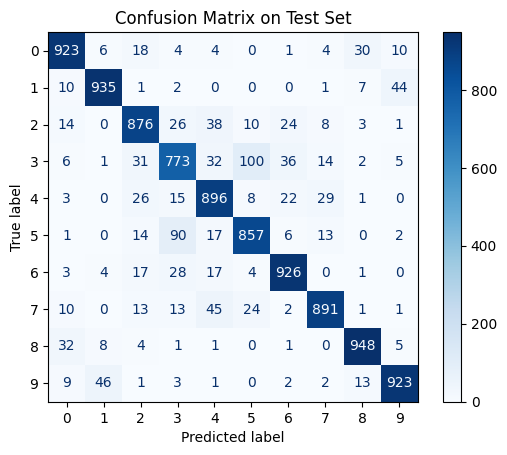

In [93]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_test = model.predict(X_test_mlp_resnet)      # Plot confusion matrix
y_pred_labels = np.argmax(y_pred_test, axis=1)

cm = confusion_matrix(y_test_main, y_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix on Test Set")
plt.show()


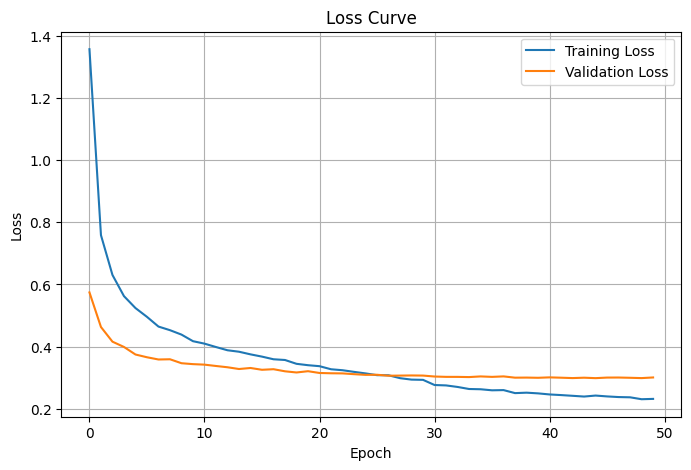

In [94]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')    # Plot loss curve
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

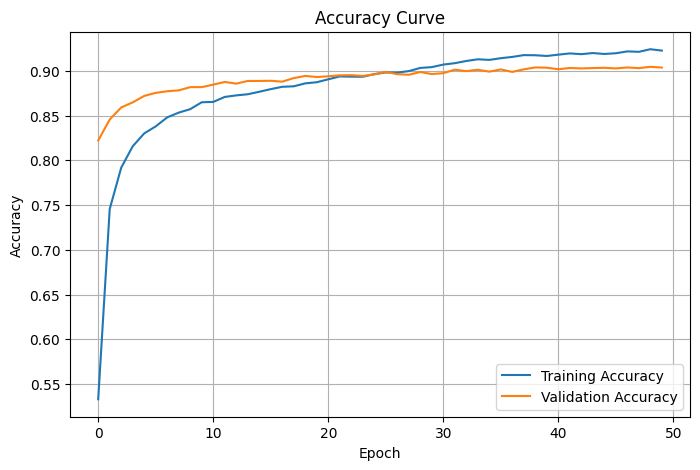

In [95]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['accuracy'], label='Training Accuracy')     # Plot accuracy curve
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()